In [ ]:
#Groupmates: Regina Martinez, Lauren Nunez, Saam Grami

In [ ]:
'''
Project Objective
Estimate the intrinsic and extrinsic parameters of the laptop camera, 
then verify those parameters by
comparing predicted object positions with manual 
measurements in both camera and world frames.

Slide 9 
    Intrinsic parameters - fx, fy, or, oc, Sx, Sy, and λ are known as the 
        intrinsic parameters which is related to the camera itself
    Extrinsic parameters - are another group of parameters, describing the relationship
        between the camera frame and the world frame in a 3D space
'''

'''
Preparation
1. Review the camera projection model together with intrinsic and extrinsic parameters.
2. Establish a right-hand-rule camera frame and world frame for the laptop setup.
3. Use a Python-based camera-calibration workflow to estimate the camera parameters
'''

'''
Verification Procedure
1. Keep the laptop and camera fixed throughout the verification process.
    So don't move laptop
2. Place an object of interest, such as a cup, on the table.
    Pick object
3. Capture an image of the object with the laptop camera.
    Use previous camera code
4. Manually determine the pixel coordinates of the object in the image.
    Not too sure how to do that other than having tick marks projected onto 
    the image to find the relative area
5. Manually measure the object's z coordinate with respect to the camera frame.
6. In Python, compute the object's x and y coordinates in the camera frame 
    using the camera projection model.
    Slide 
7. Use a coordinate transformation to compute the object's coordinates in the world frame.
8. Manually measure the object's world-frame coordinates and compare them with 
    the computed values.
9. Repeat the procedure for five different object locations.

'''

"\nVerification Procedure\n1. Keep the laptop and camera fixed throughout the verification process.\n2. Place an object of interest, such as a cup, on the table.\n3. Capture an image of the object with the laptop camera.\n4. Manually determine the pixel coordinates of the object in the image.\n5. Manually measure the object's z coordinate with respect to the camera frame.\n6. In Python, compute the object's x and y coordinates in the camera frame \n    using the camera projection model.\n7. Use a coordinate transformation to compute the object's coordinates in the world frame.\n8. Manually measure the object's world-frame coordinates and compare them with \n    the computed values.\n9. Repeat the procedure for five different object locations.\n\n"

In [ ]:
'''

How I think we are going to do this:
1. Takes pictures of checker board with the test computer's camera
2. Get intrinsic camera matrix values
3. Get extrinsic values from having the world frame checkbox in from a picture 

'''

In [ ]:
import cv2

In [ ]:

'''
Instrinsic - checkboard pictures, run open cv calibration, get k and distortion coeff
Extrinsic  - have checkerboard, pick one corner as world edges, take picture with board, 
    run solvePNP R and T values, do not move computer
Verification camera frame - place object in frame, take photo, find center of object, 
    record pixel, find object z val with ruler, use k and ruler val 
    to find x,y,z camera frame of object
World frame - apply r and t to camera frame coordinates, find objects world frame coords 
    with ruler, compute error between measured and calcualted
'''

In [ ]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 
import cv2
import numpy as np
import os
import glob
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)
images = glob.glob('/home/regina2004/mtre_4820/.venv/calibration_images/*.jpg')
 
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    cv2.imshow('img',img)
    cv2.waitKey(0)
 
cv2.destroyAllWindows()
 
h,w = img.shape[:2]
 
"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")


pixel_coords = insert()




NameError: name 'img' is not defined

In [ ]:
#Extrinsic

#Solve PnP means perspective n point
#Just run the code for one picture


In [1]:
'''
Pseudo code verification

Take camera frame
Run solve pnp and return R and t
Record the origin
Place object into view
Take new picture
Click on center of object 
(Insert) Record pixel 
(Insert) Manual measure object z value
Use camera matrix K to find objects x and y values
Combine x,y,z values into a coordinate
Calculate world frame from camera by applying R and t coordinates to camera frame
(Insert) Find objects world frame with a ruler
Compare the two world frame results

'''

'\nPseudo code verification\n\nTake camera frame\nRun solve pnp and return R and t\nRecord the origin\nPlace object into view\nTake new picture\nClick on center of object \n(Insert) Record pixel \n(Insert) Manual measure object z value\nUse camera matrix K to find objects x and y values\nCombine x,y,z values into a coordinate\nCalculate world frame from camera by applying R and t coordinates to camera frame\n(Insert) Find objects world frame with a ruler\nCompare the two world frame results\n\n'

In [2]:
import cv2
import numpy as np
import os
import glob


In [3]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)
img = cv2.imread('test_frame.jpg')
 

In [ ]:

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# Find the chess board corners
# If desired number of corners are found in the image then ret = true
ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
print("Chess board corners found")
"""
If desired number of corner are detected,
we refine the pixel coordinates and display
them on the images of checker board
"""
if ret == True:
    objpoints.append(objp)
    # refining pixel coordinates for given 2d points.
    corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
    
    imgpoints.append(corners2)

    # Draw and display the corners
    img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
print("ret was equal to True")
    
cv2.imshow('img',img)
cv2.waitKey(0)
 
cv2.destroyAllWindows()
 
h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)


#We now have the camera matrix, distortion coeff, t vecotr, R vector



Chess board corners found
ret was equal to True
Camera matrix : 

[[1.45716281e+03 0.00000000e+00 9.43173040e+02]
 [0.00000000e+00 3.64707974e+03 5.05622436e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 2.91658526e-01 -1.67334540e+01  3.06727592e-03 -3.96677670e-03
   2.14638810e+02]]
rvecs : 

(array([[-1.10396195],
       [-1.03093987],
       [-1.24177629]]), array([[-1.10413151],
       [-1.0298448 ],
       [-1.24161331]]))
tvecs : 



In [ ]:
#Reference: https://techvidvan.com/tutorials/displaying-the-coordinates-of-points-clicked-on-the-image-using-python-opencv/

#Loads image in a window and you can click on it to get the coordinate directly instead of using MS Paint

image = cv2.imread('test_frame.jpg')
#Resize to fit on screen
image = cv2.resize(image, (900, 600))
#Initializ u and v variables for pixel coordinates
u_coordinate = 0
v_coordinate = 0

def point_capture(event, x, y, flags, params):
    global u_coordinate, v_coordinate
    if event == cv2.EVENT_LBUTTONDOWN:
        #save clicked pixel
        u_coordinate = x
        v_coordinate = y
        print(f"Coordinate of Image: ({x}, {y})")
        cv2.putText(image, f'({x}, {y})', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        cv2.imshow('image', image)

cv2.imshow('image', image)
cv2.setMouseCallback('image', point_capture)
cv2.waitKey(0)
cv2.destroyAllWindows()

print("Saved: u=", u_coordinate, ", v=", v_coordinate)

In [ ]:
#Getting the camera frame

# Getting the intrinsic values from the calibration 

#focal length in x direction
fx = mtx[0, 0]
#Focal length in y direction
fy = mtx[1, 1]
#Image center x coordinate
cx = mtx[0, 2]
#Image center y coordinate
cy = mtx[1, 2]

#Pixel coordinates from cell above
u_point = u_coordinate
v_point = v_coordinate
  
#Distance from camera to the object
z_dist = 42.5

#X distance from camera
x_cam = (u_point - cx) * (z_dist / fx)
print("x:", x_cam)
#Y distance from camera
y_cam = (v_point - cy) * (z_dist / fy)
print("y:", y_cam)

#Store camera frame for objects positions (xc, yc, zc)
object_position_camera = (x_cam, y_cam, z_dist)
print("Object position in camera:", object_position_camera)


In [ ]:
'''
Verification camera frame - place object in frame, take photo, find center of object, 
    record pixel, find object z val with ruler, use k and ruler val 
    to find x,y,z camera frame of object
'''

center_pixel_object = (1600, 690)
z_value_object = 430 #in millimeters, camera frame to object

#use K camera matrix and ruler value to find x,y,z, of camera frame of object

u = -Sx(r-o_r)
v = -Sy(c-o_c)
u = h*x/2
v = h*y/2

fx = h/Sx
fy = h/Sy
x = (r-o_r)*z/fx
y = (c-o_c)*z/fy

'''

camera intrinsic matrix = [fx 0  0;
                           0  fy 0;
                           or oc 1]
camere coordinate fromae (Xc,Yc,Zc) unit in meters
pixel coordinate frame (r,c) unit in pixels
    r - width, like left and right, so from cv2 this is x
    c - height, like up and down, so from cv2 this is y
principle point - intersection between the Zc axis and the image plane 
    (or, oc) are the coordinates of the principal point with respect to the pixel coord frame

Image plane defines two sets of coordinates
    pixel coordinate frame: (r,c) with a unit in pixels
    image coordinate frame: (u,v) with a unit in meters

Pixel definition
    Sx - width of each pixel
    Sy - height of each pixel 


Intrinsic parameters of the camera
    Sx, Sy, or, oc

Coordinate transforms 
    between pixel coord frame and image coord frame
        u = -Sx(r-or)
        v = -Sy(c-oc)

    between the image coordinate frame and the camera coordinate frame
        u = lambda(x/z)
        v = lambda(y/z)
        where (x,y,z) are the coords of P wrt camera frame
        (u,v) are coords of P wrt the image coord frame
        lambda is focal length of camera with units in meters
    
        x/z = (or-r)/fx
        y/z = (oc-c)/fy
        
        fx = lambda/Sx
        fy = lambda/Sy


    

'''




'\ncamere coordinate fromae (x,y,z) unit in meters\npixel coordinate frame (r,c) unit in pixels\n    r - width, like left and right, so from cv2 this is x\n    c - height, like up and down, so from cv2 this is y\n    '

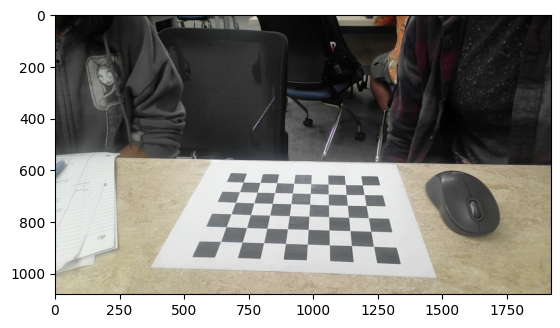

In [ ]:

#Attempt at mouse getting pixel
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def onclick(event):
    print(f'Pixel Coordinates: x={int(event.xdata)}, y={int(event.ydata)}')

# Load image
img = mpimg.imread('test_frame.jpg')
fig, ax = plt.subplots()
ax.imshow(img)

# Connect the click event
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()
